In [ ]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

In [ ]:
(ds_train, ds_test), info = tfds.load(
    "cifar100",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar100/incomplete.BPNTE8_3.0.2/cifar100-train.tfrecord*...:   0%|       …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar100/incomplete.BPNTE8_3.0.2/cifar100-test.tfrecord*...:   0%|        …

Dataset cifar100 downloaded and prepared to /root/tensorflow_datasets/cifar100/3.0.2. Subsequent calls will reuse this data.


In [ ]:
def preprocess(image, label):
    image = tf.image.resize(image, (224, 224))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

batch_size = 4  # RAM SAFE

ds_train = ds_train.map(preprocess).batch(batch_size).prefetch(1)
ds_test = ds_test.map(preprocess).batch(batch_size).prefetch(1)

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    pooling="avg",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
def extract_features(x):
    return base_model(x, training=False)

In [ ]:
classifier = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(100)
])

In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))

features = extract_features(inputs)
outputs = classifier(features)

model = tf.keras.Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [20]:
history = model.fit(
    ds_train,
    validation_data=ds_test,
    epochs=10
)

Epoch 1/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 2278s 181ms/step - accuracy: 0.3149 - loss: 2.7781 - val_accuracy: 0.4891 - val_loss: 1.9142
Epoch 2/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 2291s 183ms/step - accuracy: 0.4792 - loss: 1.9324 - val_accuracy: 0.5321 - val_loss: 1.6903
Epoch 3/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 2323s 186ms/step - accuracy: 0.5211 - loss: 1.7323 - val_accuracy: 0.5558 - val_loss: 1.6200
Epoch 4/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 2291s 183ms/step - accuracy: 0.5549 - loss: 1.6042 - val_accuracy: 0.5639 - val_loss: 1.5679
Epoch 5/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 2270s 182ms/step - accuracy: 0.5773 - loss: 1.5064 - val_accuracy: 0.5712 - val_loss: 1.5515
Epoch 6/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 2287s 183ms/step - accuracy: 0.5951 - loss: 1.4325 - val_accuracy: 0.5772 - val_loss: 1.5169
Epoch 7/10
12500/12500 ━━━━━━━━━━━━━━━━━━━━ 2260s 181ms/step - accuracy: 0.6137 - loss: 1.3622 - val_accuracy: 0.5847 - val_loss: 1.5091
Epoch 8/10
12500/12500 ━━━━━━━━━━━━━━━━━━

In [21]:
model.evaluate(ds_test)

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 372s 149ms/step - accuracy: 0.5856 - loss: 1.5105


[1.5105115175247192, 0.5856000185012817]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 650ms/step


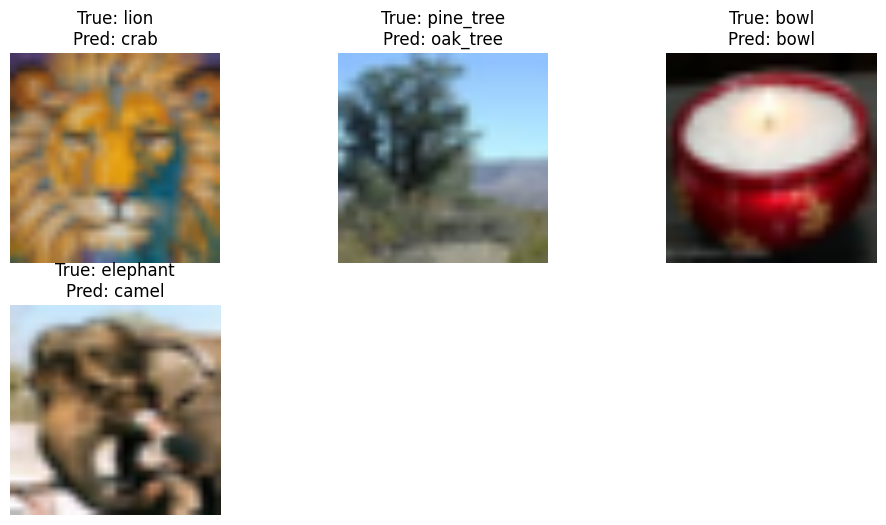

In [24]:
class_names = info.features['label'].names

for images, labels in ds_test.take(1):
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    plt.figure(figsize=(12, 6))

    for i in range(min(6, images.shape[0])):
        plt.subplot(2, 3, i+1)
        plt.imshow(images[i].numpy())
        plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[pred_labels[i]]}")
        plt.axis("off")

    plt.show()

In [25]:
model.save("cifar100_model.h5")

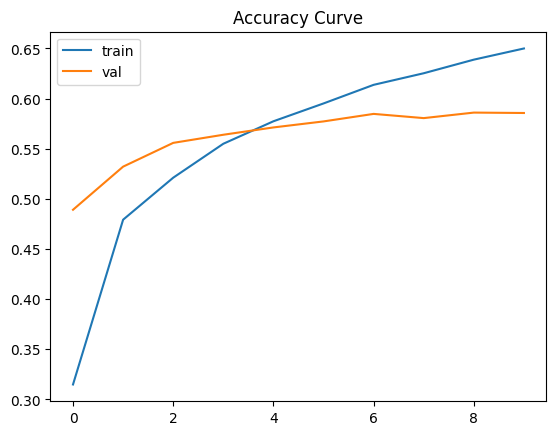

In [26]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train', 'val'])
plt.title('Accuracy Curve')
plt.show()